# Capstone-Project-24.1-Jay

In [ ]:
# ============================================================================
# CREDIT CARD FRAUD DETECTION - CAPSTONE PROJECT
# ============================================================================
# Research Question: Can machine learning models accurately identify
# fraudulent transactions, and which features are most predictive of fraud?
# ============================================================================

# ============================================================================
# 1. IMPORT LIBRARIES
# ============================================================================

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score, precision_score,
                             recall_score, auc)

In [ ]:
# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [ ]:
# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Handle imbalanced data
from imblearn.over_sampling import SMOTE

# Feature importance and interpretability
import shap

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")


All libraries imported successfully!


In [ ]:
# LOAD AND EXPLORE THE DATASET
# ============================================================================

# Load the credit card fraud dataset
# Note: Update the path to where you've downloaded the creditcard.csv file
df = pd.read_csv('creditcard.csv')

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Transactions: {df.shape[0]:,}")
print(f"Number of Features: {df.shape[1]}")

# Display first few rows
print("\n" + "=" * 80)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 80)
print(df.head())

# Dataset information
print("\n" + "=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(df.info())

# Statistical summary
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
print(df.describe())

# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES CHECK")
print("=" * 80)
missing_values = df.isnull().sum()
print(f"Total missing values: {missing_values.sum()}")
if missing_values.sum() > 0:
    print("\nMissing values by column:")
    print(missing_values[missing_values > 0])
else:
    print("No missing values found in the dataset!")

# Check for duplicate rows
print("\n" + "=" * 80)
print("DUPLICATE ROWS CHECK")
print("=" * 80)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


DATASET OVERVIEW

Dataset Shape: (29799, 31)
Number of Transactions: 29,799
Number of Features: 31

FIRST 5 ROWS OF THE DATASET
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.17557


CLASS DISTRIBUTION ANALYSIS

Transaction Class Distribution:
Legitimate Transactions (Class 0): 29,704 (99.6845%)
Fraudulent Transactions (Class 1): 94 (0.3155%)

Class Imbalance Ratio: 1:316


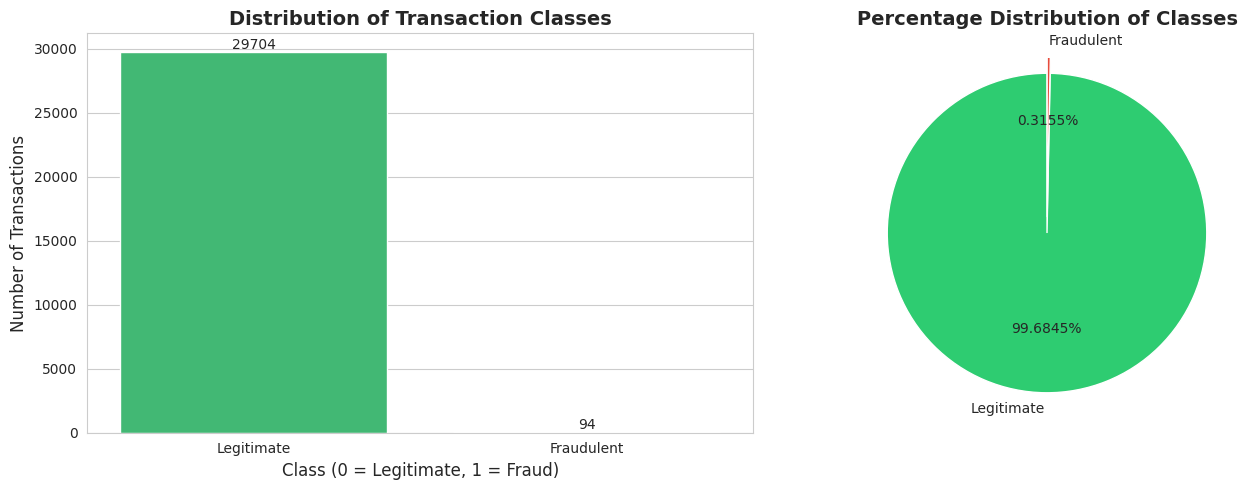


TRANSACTION AMOUNT ANALYSIS

Amount Statistics by Class:
         count      mean         std  min     25%    50%      75%      max
Class                                                                     
0.0    29704.0  79.57003  221.991154  0.0  6.6375  20.00  70.6525  7879.42
1.0       94.0  95.59000  257.920621  0.0  1.0000   1.05  99.9900  1809.68


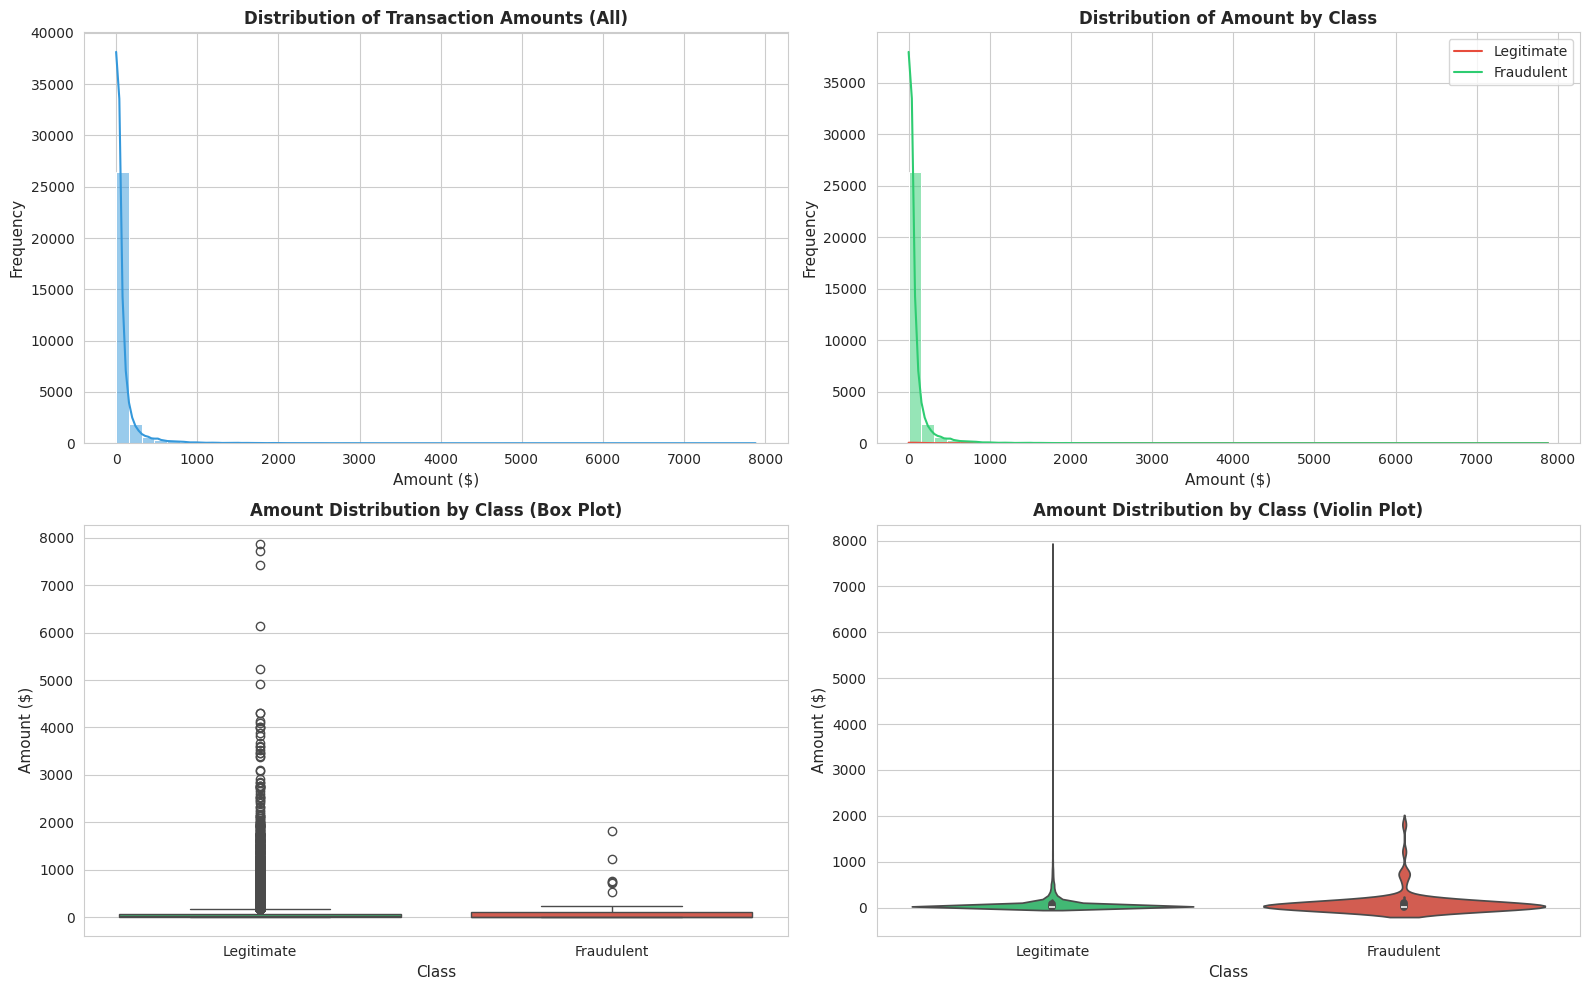


TIME ANALYSIS

Time Statistics by Class:
         count          mean           std    min      25%      50%       75%  \
Class                                                                           
0.0    29704.0  21422.566422  12045.173999    0.0  10126.5  26200.0  32205.25   
1.0       94.0  19007.702128   9430.939932  406.0   8930.5  18682.5  27181.00   

           max  
Class           
0.0    35634.0  
1.0    35585.0  


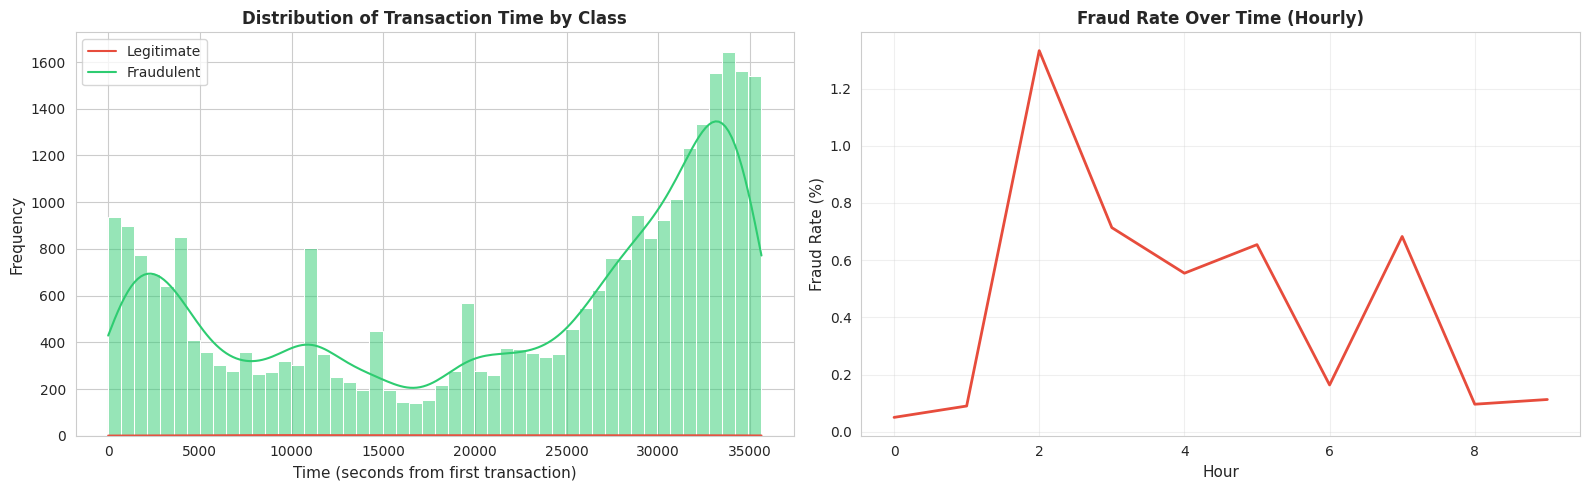


CORRELATION ANALYSIS

Top 10 Features Most Correlated with Fraud:
V11    0.251979
V4     0.229981
V2     0.217198
V8     0.175307
V27    0.118511
V20    0.054315
V21    0.043459
V25    0.028382
V19    0.023309
V28    0.019789
Name: Class, dtype: float64

Top 10 Features Most Negatively Correlated with Fraud:
V18   -0.172248
V5    -0.217145
V1    -0.240479
V16   -0.287129
V12   -0.299084
V10   -0.324720
V7    -0.339350
V17   -0.399393
V14   -0.404681
V3    -0.428325
Name: Class, dtype: float64


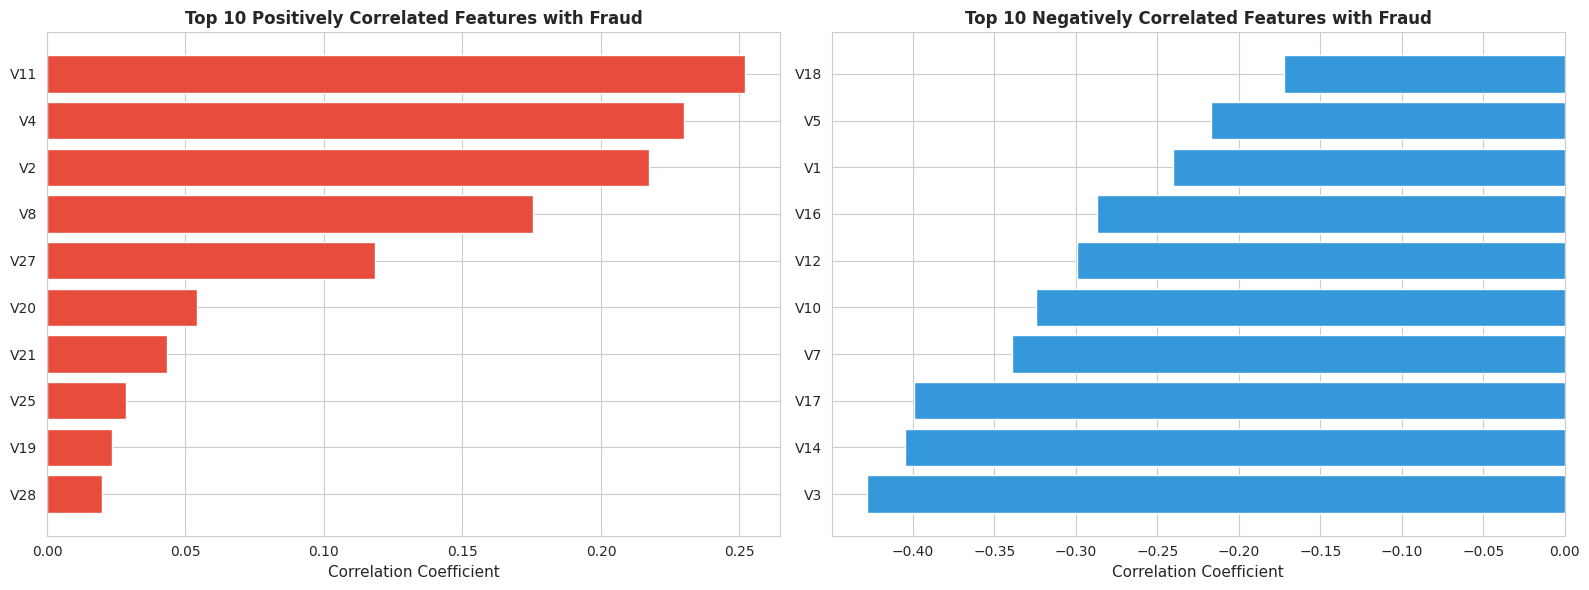

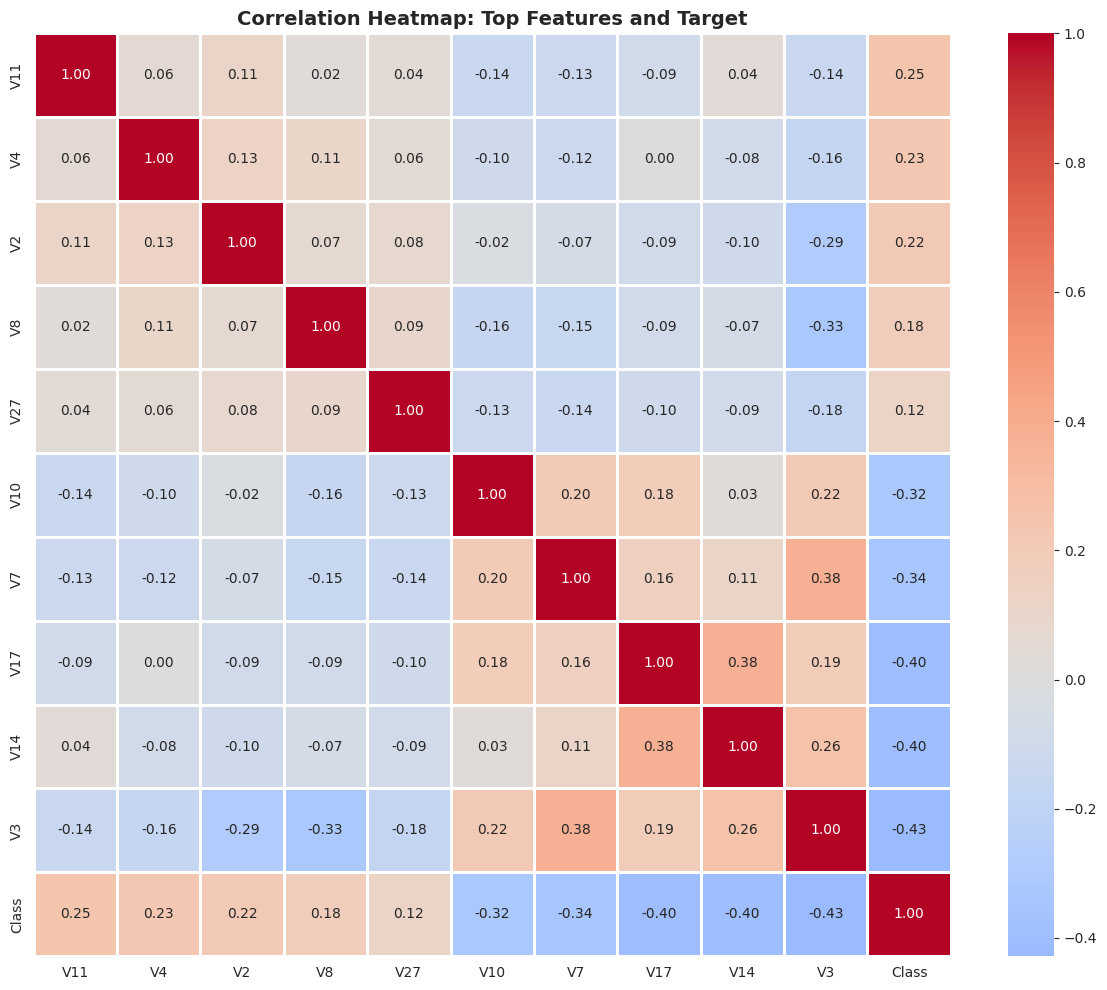

In [ ]:
# ============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "=" * 80)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 80)

# Class distribution
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

print("\nTransaction Class Distribution:")
print(f"Legitimate Transactions (Class 0): {class_counts[0]:,} ({class_percentages[0]:.4f}%)")
print(f"Fraudulent Transactions (Class 1): {class_counts[1]:,} ({class_percentages[1]:.4f}%)")
print(f"\nClass Imbalance Ratio: 1:{class_counts[0]/class_counts[1]:.0f}")

# Visualization 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='Class', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Distribution of Transaction Classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (0 = Legitimate, 1 = Fraud)', fontsize=12)
axes[0].set_ylabel('Number of Transactions', fontsize=12)
axes[0].set_xticklabels(['Legitimate', 'Fraudulent'])

# Add count labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(class_counts, labels=['Legitimate', 'Fraudulent'], autopct='%1.4f%%',
            colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Percentage Distribution of Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Visualization 2: Transaction Amount Analysis
print("\n" + "=" * 80)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 80)

print("\nAmount Statistics by Class:")
print(df.groupby('Class')['Amount'].describe())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribution of Amount for all transactions
sns.histplot(data=df, x='Amount', bins=50, kde=True, ax=axes[0, 0], color='#3498db')
axes[0, 0].set_title('Distribution of Transaction Amounts (All)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Amount ($)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)

# Distribution by class
sns.histplot(data=df, x='Amount', hue='Class', bins=50, kde=True,
             palette=['#2ecc71', '#e74c3c'], ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Amount by Class', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Amount ($)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend(['Legitimate', 'Fraudulent'])

# Box plot comparison
sns.boxplot(data=df, x='Class', y='Amount', palette=['#2ecc71', '#e74c3c'], ax=axes[1, 0])
axes[1, 0].set_title('Amount Distribution by Class (Box Plot)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Class', fontsize=11)
axes[1, 0].set_ylabel('Amount ($)', fontsize=11)
axes[1, 0].set_xticklabels(['Legitimate', 'Fraudulent'])

# Violin plot
sns.violinplot(data=df, x='Class', y='Amount', palette=['#2ecc71', '#e74c3c'], ax=axes[1, 1])
axes[1, 1].set_title('Amount Distribution by Class (Violin Plot)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Class', fontsize=11)
axes[1, 1].set_ylabel('Amount ($)', fontsize=11)
axes[1, 1].set_xticklabels(['Legitimate', 'Fraudulent'])

plt.tight_layout()
plt.show()

# Visualization 3: Time Analysis
print("\n" + "=" * 80)
print("TIME ANALYSIS")
print("=" * 80)

print("\nTime Statistics by Class:")
print(df.groupby('Class')['Time'].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time distribution
sns.histplot(data=df, x='Time', hue='Class', bins=50, kde=True,
             palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Distribution of Transaction Time by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time (seconds from first transaction)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend(['Legitimate', 'Fraudulent'])

# Fraud rate over time
df['Time_Hour'] = df['Time'] // 3600
fraud_rate_time = df.groupby('Time_Hour')['Class'].mean() * 100
fraud_rate_time.plot(kind='line', ax=axes[1], color='#e74c3c', linewidth=2)
axes[1].set_title('Fraud Rate Over Time (Hourly)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour', fontsize=11)
axes[1].set_ylabel('Fraud Rate (%)', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization 4: Correlation Analysis for PCA Features
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Select V features for correlation
v_features = [col for col in df.columns if col.startswith('V')]

# Correlation with target
correlation_with_target = df[v_features + ['Class']].corr()['Class'].drop('Class').sort_values(ascending=False)

print("\nTop 10 Features Most Correlated with Fraud:")
print(correlation_with_target.head(10))

print("\nTop 10 Features Most Negatively Correlated with Fraud:")
print(correlation_with_target.tail(10))

# Visualization of top correlations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive correlations
top_positive = correlation_with_target.head(10)
axes[0].barh(range(len(top_positive)), top_positive.values, color='#e74c3c')
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive.index)
axes[0].set_xlabel('Correlation Coefficient', fontsize=11)
axes[0].set_title('Top 10 Positively Correlated Features with Fraud', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Negative correlations
top_negative = correlation_with_target.tail(10)
axes[1].barh(range(len(top_negative)), top_negative.values, color='#3498db')
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative.index)
axes[1].set_xlabel('Correlation Coefficient', fontsize=11)
axes[1].set_title('Top 10 Negatively Correlated Features with Fraud', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Heatmap of top correlated features
top_features = list(correlation_with_target.head(5).index) + list(correlation_with_target.tail(5).index)
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features + ['Class']].corr(), annot=True, cmap='coolwarm',
            center=0, fmt='.2f', linewidths=1)
plt.title('Correlation Heatmap: Top Features and Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================================
# 4. DATA PREPROCESSING
# ============================================================================

print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

# Create a copy for preprocessing
df_processed = df.copy()

# Scale 'Time' and 'Amount' features
# Note: V1-V28 are already PCA-transformed and scaled
scaler = StandardScaler()
df_processed['Time_Scaled'] = scaler.fit_transform(df_processed[['Time']])
df_processed['Amount_Scaled'] = scaler.fit_transform(df_processed[['Amount']])

print("\nScaling completed for 'Time' and 'Amount' features.")

# Drop original Time and Amount, and Time_Hour
df_processed = df_processed.drop(['Time', 'Amount', 'Time_Hour'], axis=1)

print(f"\nProcessed dataset shape: {df_processed.shape}")
print("\nFirst 5 rows of processed data:")
print(df_processed.head())


DATA PREPROCESSING

Scaling completed for 'Time' and 'Amount' features.

Processed dataset shape: (29799, 31)

First 5 rows of processed data:
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.

In [ ]:
# ============================================================================
# 5. TRAIN-TEST SPLIT
# ============================================================================

print("\n" + "=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)

# Drop rows with NaN values from the processed DataFrame
df_processed.dropna(inplace=True)

# Separate features and target
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]:,} samples")
print(f"Test set size: {X_test.shape[0]:,} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())


TRAIN-TEST SPLIT

Training set size: 23,838 samples
Test set size: 5,960 samples

Training set class distribution:
Class
0.0    23763
1.0       75
Name: count, dtype: int64

Test set class distribution:
Class
0.0    5941
1.0      19
Name: count, dtype: int64



HANDLING CLASS IMBALANCE WITH SMOTE

Original training set class distribution:
Class
0.0    23763
1.0       75
Name: count, dtype: int64

Balanced training set class distribution:
Class
0.0    23763
1.0    23763
Name: count, dtype: int64


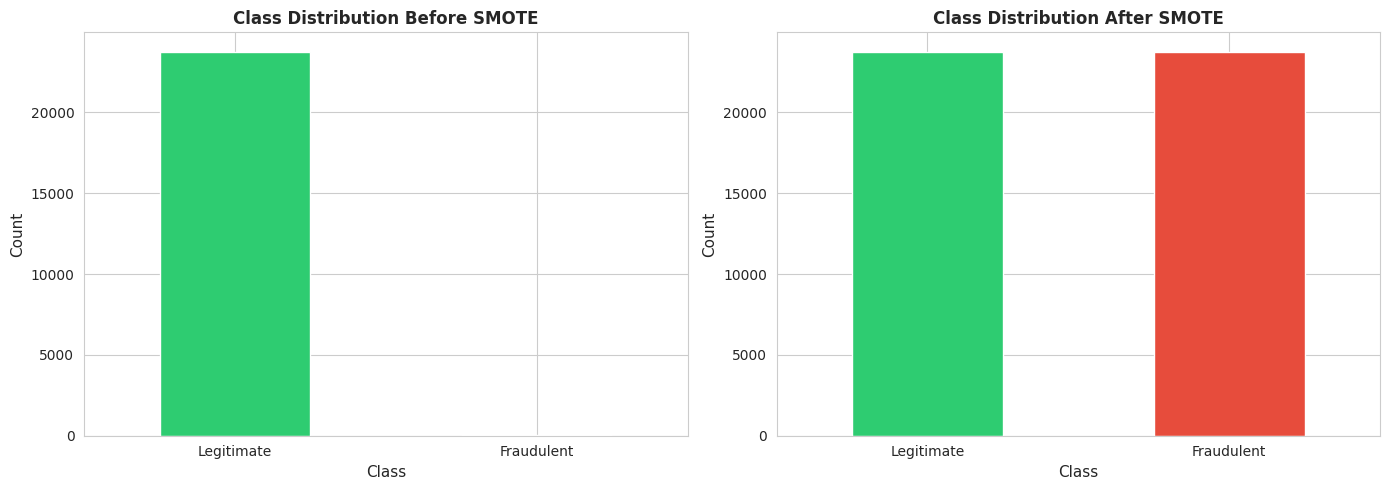

In [ ]:
# ============================================================================
# 6. HANDLE CLASS IMBALANCE WITH SMOTE
# ============================================================================

print("\n" + "=" * 80)
print("HANDLING CLASS IMBALANCE WITH SMOTE")
print("=" * 80)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nOriginal training set class distribution:")
print(y_train.value_counts())
print(f"\nBalanced training set class distribution:")
print(y_train_balanced.value_counts())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)

# After SMOTE
y_train_balanced.value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Class Distribution After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# 7. MODEL TRAINING AND EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("MODEL TRAINING AND EVALUATION")
print("=" * 80)

# Dictionary to store model results
model_results = {}

# Function to evaluate models
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    """
    Train and evaluate a machine learning model.
    Returns comprehensive evaluation metrics.
    """
    print(f"\n{'=' * 80}")
    print(f"TRAINING AND EVALUATING: {model_name}")
    print(f"{'=' * 80}")

    # Train the model
    model.fit(X_train, y_train)
    print(f"? {model_name} training completed.")

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Print results
    print(f"\n{model_name} Performance Metrics:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  Precision-Recall AUC: {pr_auc:.4f}")

    print(f"\nConfusion Matrix:")
    print(f"  True Negatives:  {tn:,}")
    print(f"  False Positives: {fp:,}")
    print(f"  False Negatives: {fn:,}")
    print(f"  True Positives:  {tp:,}")

    # Store results
    results = {
        'model': model,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    return results


MODEL TRAINING AND EVALUATION


In [ ]:
# ============================================================================
# 7.1 LOGISTIC REGRESSION
# ============================================================================

lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')
model_results['Logistic Regression'] = evaluate_model(
    lr_model, 'Logistic Regression',
    X_train_balanced, y_train_balanced, X_test, y_test
)

# ============================================================================
# 7.2 DECISION TREE
# ============================================================================

dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
model_results['Decision Tree'] = evaluate_model(
    dt_model, 'Decision Tree',
    X_train_balanced, y_train_balanced, X_test, y_test
)

# ============================================================================
# 7.3 RANDOM FOREST
# ============================================================================

rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, n_jobs=-1)
model_results['Random Forest'] = evaluate_model(
    rf_model, 'Random Forest',
    X_train_balanced, y_train_balanced, X_test, y_test
)

# ============================================================================
# 7.4 XGBOOST
# ============================================================================

xgb_model = xgb.XGBClassifier(random_state=42, n_estimators=100, max_depth=6,
                               learning_rate=0.1, use_label_encoder=False,
                               eval_metric='logloss')
model_results['XGBoost'] = evaluate_model(
    xgb_model, 'XGBoost',
    X_train_balanced, y_train_balanced, X_test, y_test
)


TRAINING AND EVALUATING: Logistic Regression
? Logistic Regression training completed.

Logistic Regression Performance Metrics:
  Precision: 0.1538
  Recall: 0.9474
  F1-Score: 0.2647
  ROC-AUC: 0.9734
  Precision-Recall AUC: 0.7072

Confusion Matrix:
  True Negatives:  5,842
  False Positives: 99
  False Negatives: 1
  True Positives:  18

TRAINING AND EVALUATING: Decision Tree
? Decision Tree training completed.

Decision Tree Performance Metrics:
  Precision: 0.5455
  Recall: 0.9474
  F1-Score: 0.6923
  ROC-AUC: 0.9727
  Precision-Recall AUC: 0.6317

Confusion Matrix:
  True Negatives:  5,926
  False Positives: 15
  False Negatives: 1
  True Positives:  18

TRAINING AND EVALUATING: Random Forest
? Random Forest training completed.

Random Forest Performance Metrics:
  Precision: 0.8571
  Recall: 0.9474
  F1-Score: 0.9000
  ROC-AUC: 0.9933
  Precision-Recall AUC: 0.9348

Confusion Matrix:
  True Negatives:  5,938
  False Positives: 3
  False Negatives: 1
  True Positives:  18

TRAI


MODEL COMPARISON

Model Performance Comparison:
              Model  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
Logistic Regression   0.153846 0.947368  0.264706 0.973361 0.707193
      Decision Tree   0.545455 0.947368  0.692308 0.972741 0.631747
      Random Forest   0.857143 0.947368  0.900000 0.993311 0.934770
            XGBoost   0.857143 0.947368  0.900000 0.987464 0.948066


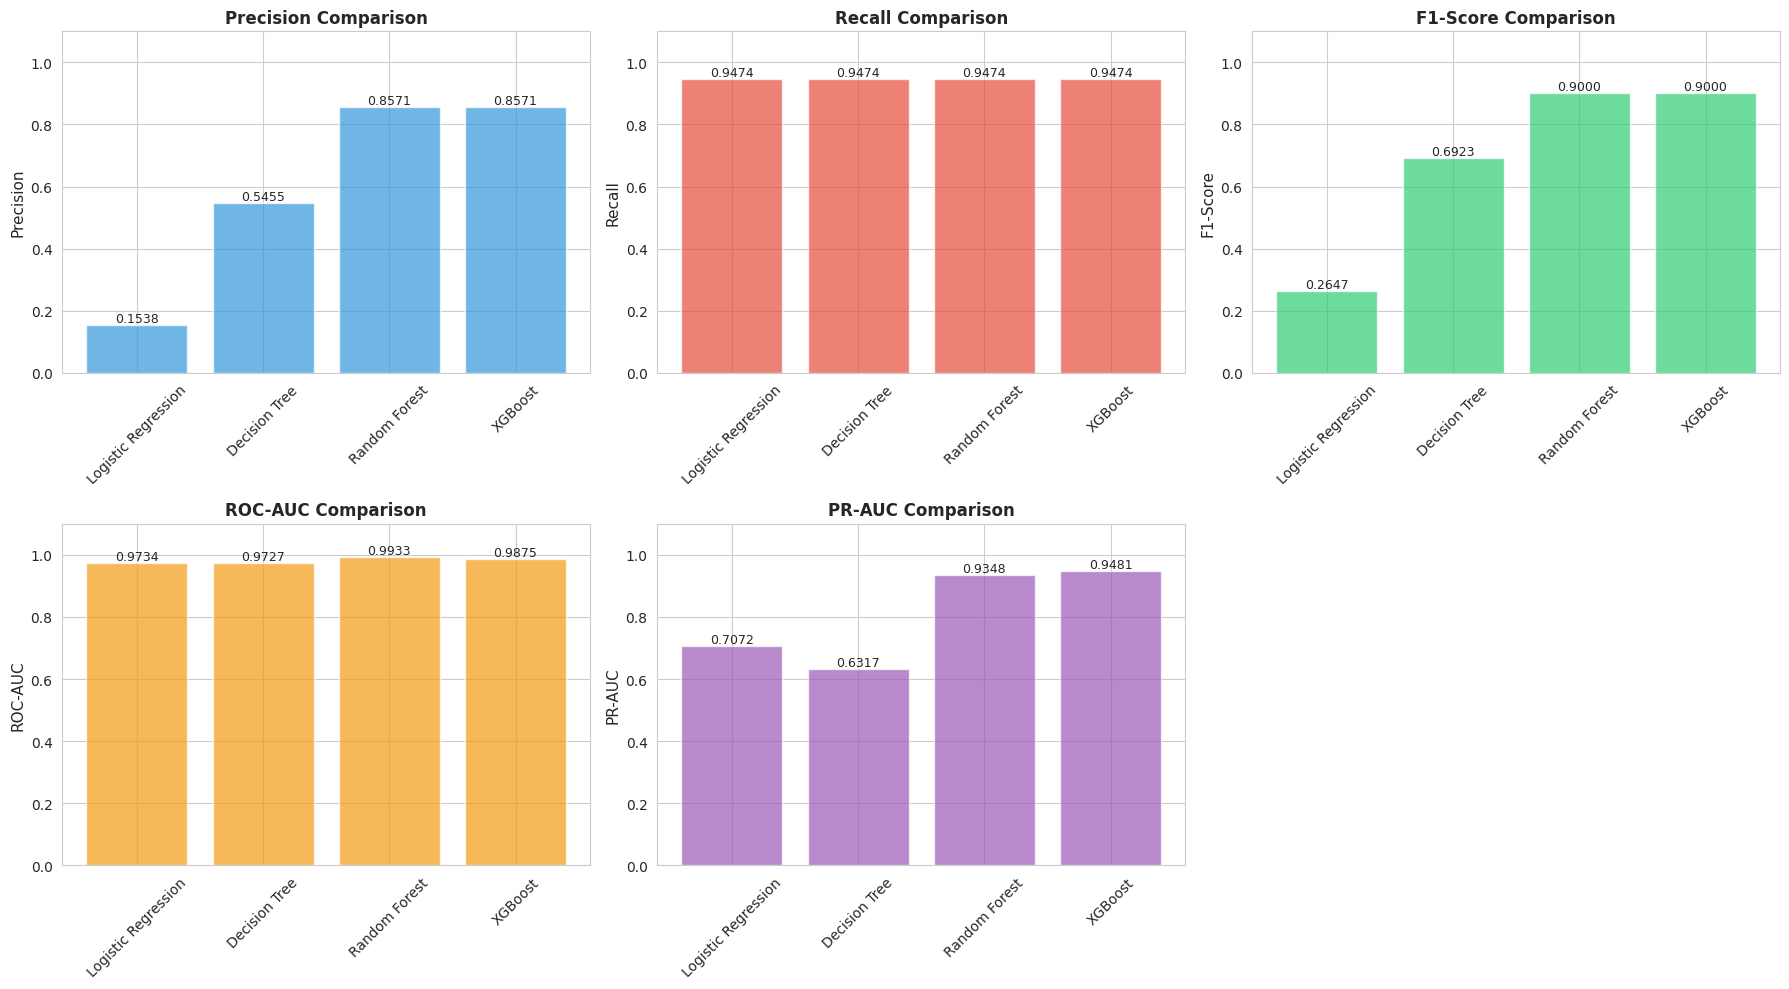

In [ ]:
# ============================================================================
# 8. MODEL COMPARISON
# ============================================================================

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Precision': [model_results[m]['precision'] for m in model_results],
    'Recall': [model_results[m]['recall'] for m in model_results],
    'F1-Score': [model_results[m]['f1_score'] for m in model_results],
    'ROC-AUC': [model_results[m]['roc_auc'] for m in model_results],
    'PR-AUC': [model_results[m]['pr_auc'] for m in model_results]
})

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualization: Model Comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=colors[idx], alpha=0.7)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.set_ylim([0, 1.1])
    ax.tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# Remove the empty subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()


CONFUSION MATRICES


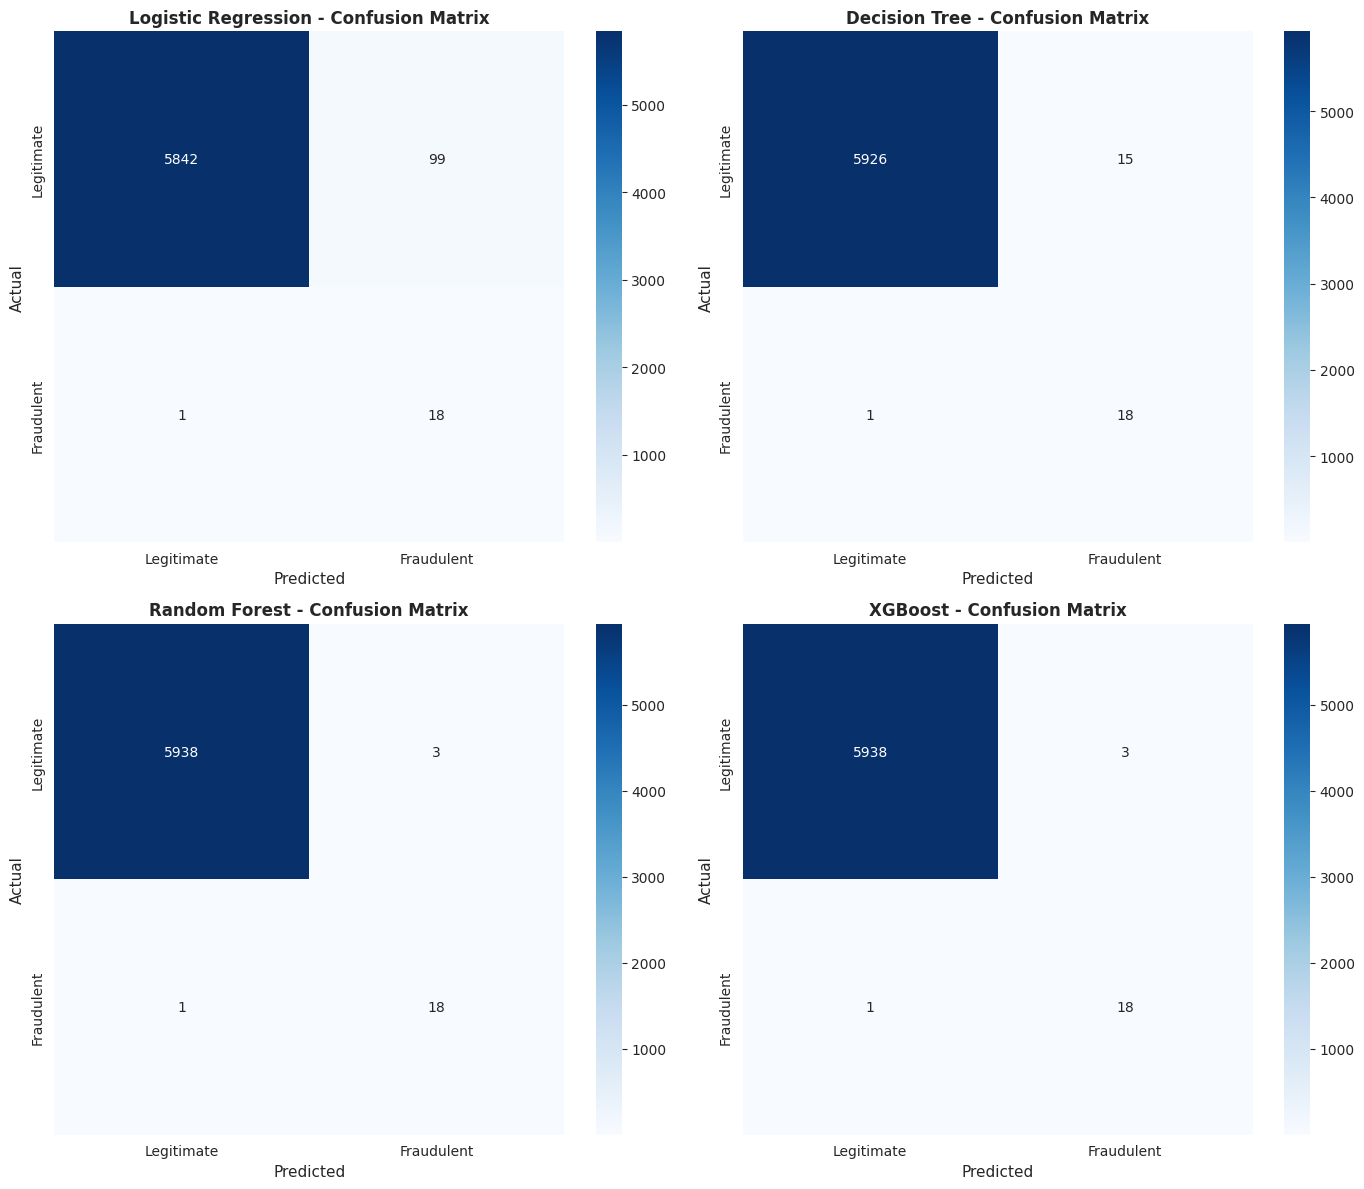

In [ ]:
# ============================================================================
# 9. CONFUSION MATRICES VISUALIZATION
# ============================================================================

print("\n" + "=" * 80)
print("CONFUSION MATRICES")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (model_name, results) in enumerate(model_results.items()):
    cm = results['confusion_matrix']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Legitimate', 'Fraudulent'],
                yticklabels=['Legitimate', 'Fraudulent'])
    axes[idx].set_title(f'{model_name} - Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()


ROC CURVES


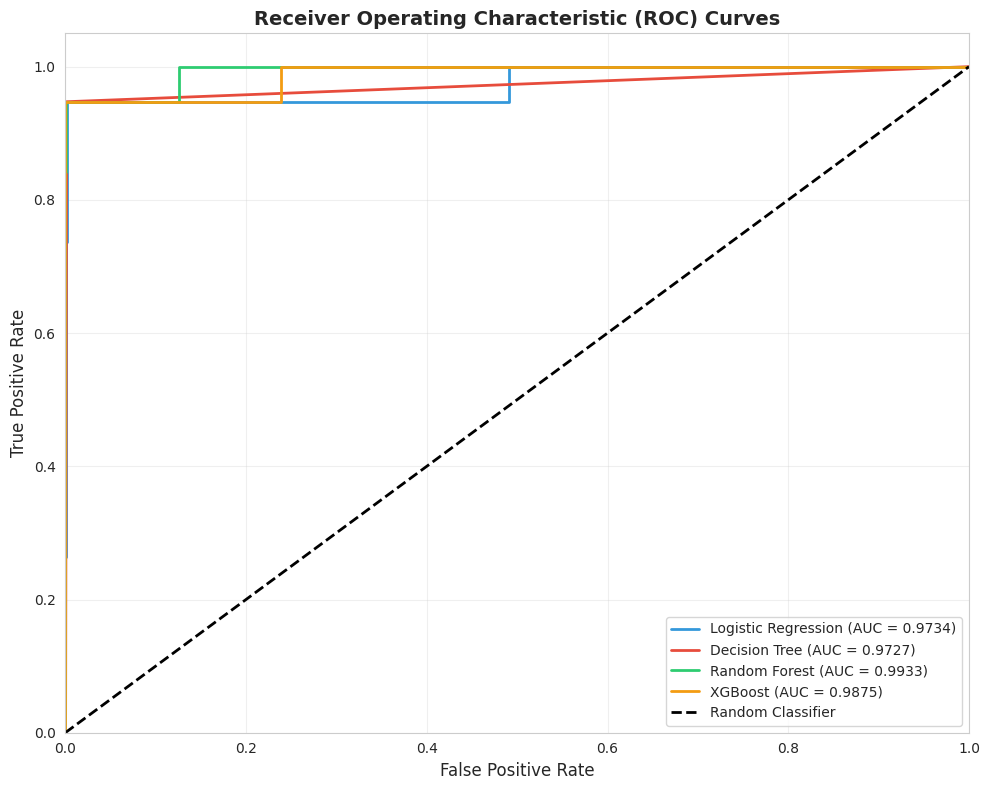

In [ ]:
# ============================================================================
# 10. ROC CURVES
# ============================================================================

print("\n" + "=" * 80)
print("ROC CURVES")
print("=" * 80)

plt.figure(figsize=(10, 8))

colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (model_name, results) in enumerate(model_results.items()):
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
    roc_auc = results['roc_auc']

    plt.plot(fpr, tpr, color=colors_roc[idx], lw=2,
             label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


PRECISION-RECALL CURVES


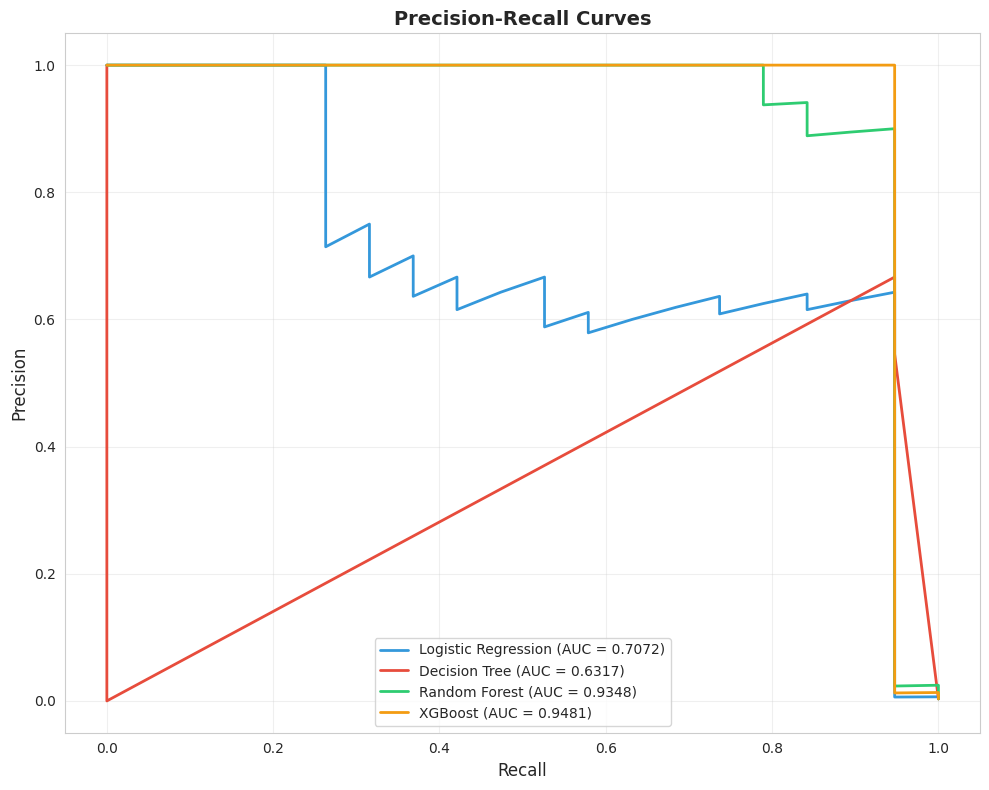

In [ ]:
# ============================================================================
# 11. PRECISION-RECALL CURVES
# ============================================================================

print("\n" + "=" * 80)
print("PRECISION-RECALL CURVES")
print("=" * 80)

plt.figure(figsize=(10, 8))

for idx, (model_name, results) in enumerate(model_results.items()):
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, results['y_pred_proba'])
    pr_auc = results['pr_auc']

    plt.plot(recall_curve, precision_curve, color=colors_roc[idx], lw=2,
             label=f'{model_name} (AUC = {pr_auc:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


CROSS-VALIDATION (5-FOLD)

Performing cross-validation for Logistic Regression...
  CV Scores: [0.99819247 0.9977763  0.99819864 0.99856147 0.99818434]
  Mean ROC-AUC: 0.9982 (+/- 0.0002)

Performing cross-validation for Decision Tree...
  CV Scores: [0.99716991 0.99797662 0.99883416 0.99888722 0.99823548]
  Mean ROC-AUC: 0.9982 (+/- 0.0006)

Performing cross-validation for Random Forest...
  CV Scores: [0.99999991 0.99999889 1.         0.99998322 0.99999982]
  Mean ROC-AUC: 1.0000 (+/- 0.0000)

Performing cross-validation for XGBoost...
  CV Scores: [0.99996264 0.99999942 0.99999942 0.99984652 0.99999903]
  Mean ROC-AUC: 1.0000 (+/- 0.0001)


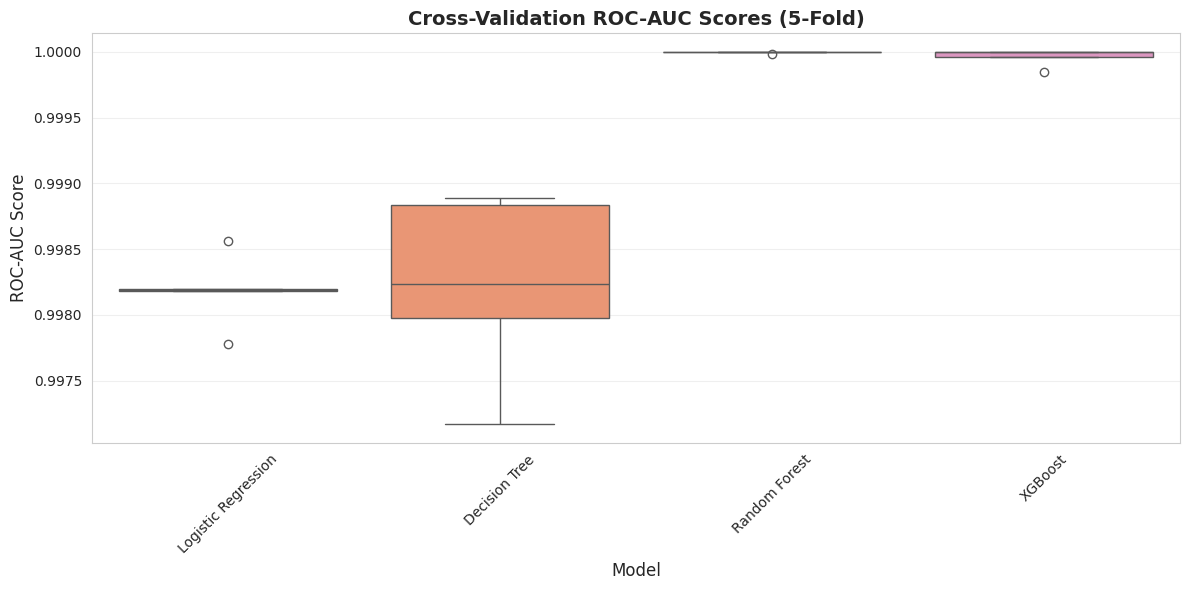

In [ ]:
# ============================================================================
# 12. CROSS-VALIDATION
# ============================================================================

print("\n" + "=" * 80)
print("CROSS-VALIDATION (5-FOLD)")
print("=" * 80)

# Use stratified k-fold for imbalanced data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

models_for_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(random_state=42, n_estimators=100, max_depth=6,
                                  learning_rate=0.1, use_label_encoder=False, eval_metric='logloss')
}

for model_name, model in models_for_cv.items():
    print(f"\nPerforming cross-validation for {model_name}...")

    # Cross-validation scores (using ROC-AUC)
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced,
                                 cv=skf, scoring='roc_auc', n_jobs=-1)

    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std()
    }

    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Visualization: Cross-Validation Results
plt.figure(figsize=(12, 6))

cv_data = []
for model_name, results in cv_results.items():
    for score in results['scores']:
        cv_data.append({'Model': model_name, 'ROC-AUC': score})

cv_df = pd.DataFrame(cv_data)

sns.boxplot(data=cv_df, x='Model', y='ROC-AUC', palette='Set2')
plt.title('Cross-Validation ROC-AUC Scores (5-Fold)', fontsize=14, fontweight='bold')
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# 13. HYPERPARAMETER TUNING WITH GRID SEARCH
# ============================================================================

print("\n" + "=" * 80)
print("HYPERPARAMETER TUNING WITH GRID SEARCH")
print("=" * 80)

# We'll tune the best performing model (typically Random Forest or XGBoost)
# For demonstration, let's tune Random Forest

print("\nTuning Random Forest hyperparameters...")

# Define parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,  # 3-fold CV to save time
    scoring='average_precision',  # Using PR-AUC as primary metric
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search_rf.fit(X_train_balanced, y_train_balanced)

print(f"\nBest Parameters: {grid_search_rf.best_params_}")
print(f"Best PR-AUC Score: {grid_search_rf.best_score_:.4f}")

# Evaluate the best model
best_rf_model = grid_search_rf.best_estimator_
model_results['Random Forest (Tuned)'] = evaluate_model(
    best_rf_model, 'Random Forest (Tuned)',
    X_train_balanced, y_train_balanced, X_test, y_test
)



HYPERPARAMETER TUNING WITH GRID SEARCH

Tuning Random Forest hyperparameters...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best PR-AUC Score: 1.0000

TRAINING AND EVALUATING: Random Forest (Tuned)
? Random Forest (Tuned) training completed.

Random Forest (Tuned) Performance Metrics:
  Precision: 0.8571
  Recall: 0.9474
  F1-Score: 0.9000
  ROC-AUC: 0.9980
  Precision-Recall AUC: 0.9312

Confusion Matrix:
  True Negatives:  5,938
  False Positives: 3
  False Negatives: 1
  True Positives:  18



FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features (Random Forest):
Feature  Importance
     V4    0.221684
    V14    0.148313
     V3    0.101978
    V10    0.100233
    V17    0.086153
    V12    0.053498
    V11    0.053253
     V2    0.031631
    V16    0.025922
     V6    0.025608
     V7    0.020594
    V19    0.016180
     V5    0.013215
    V26    0.012246
    V27    0.012191


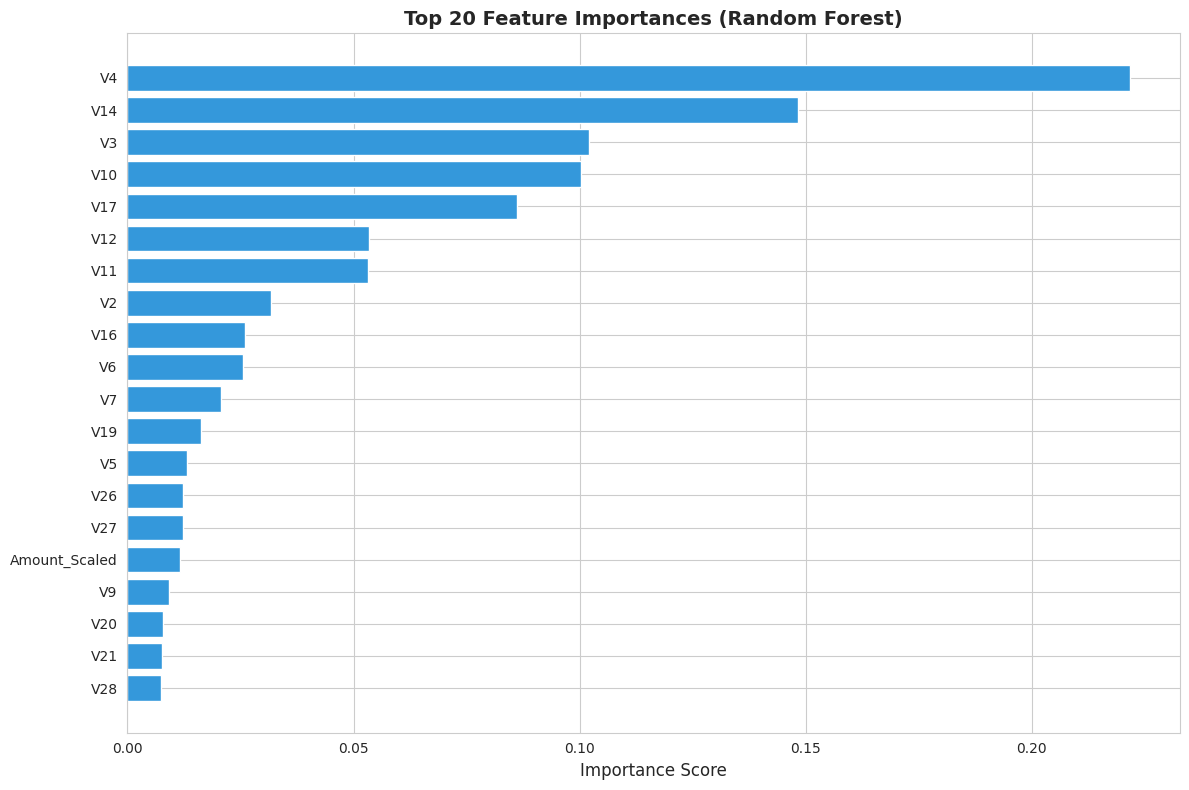

In [ ]:
# ============================================================================
# 14. FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Get feature importance from Random Forest (tuned model)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features (Random Forest):")
print(feature_importance.head(15).to_string(index=False))

# Visualization: Feature Importance
plt.figure(figsize=(12, 8))
top_features_plot = feature_importance.head(20)
plt.barh(range(len(top_features_plot)), top_features_plot['Importance'], color='#3498db')
plt.yticks(range(len(top_features_plot)), top_features_plot['Feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


SHAP VALUES ANALYSIS

Calculating SHAP values for model interpretability...
Note: This may take a few minutes...
? SHAP values calculated successfully!

Generating SHAP summary plot...


<Figure size 1200x800 with 0 Axes>

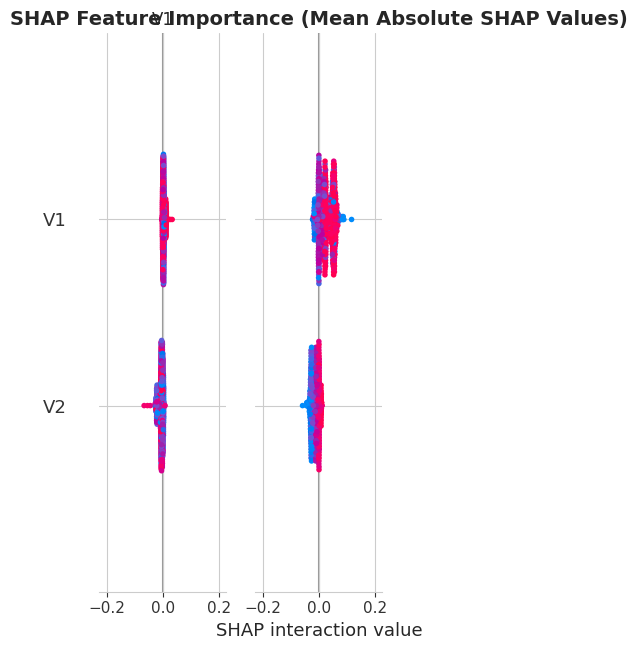


Generating detailed SHAP summary plot...


<Figure size 1200x800 with 0 Axes>

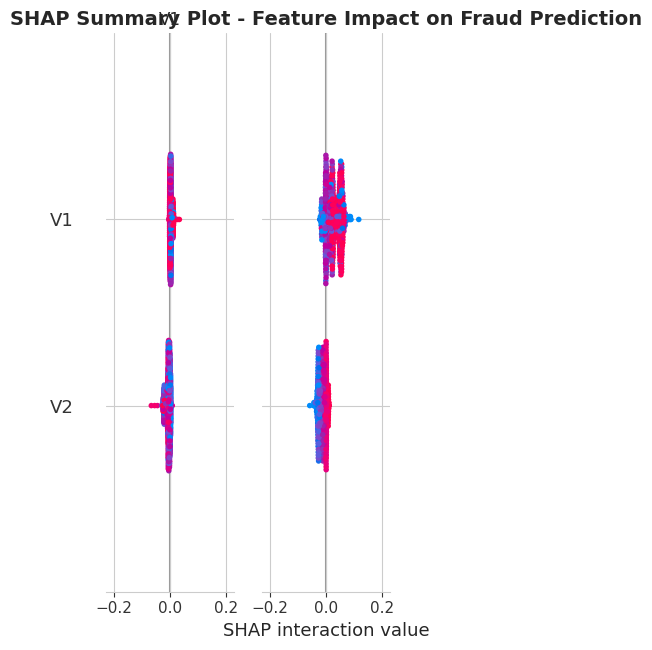

In [ ]:
# ============================================================================
# 15. SHAP VALUES FOR MODEL INTERPRETABILITY
# ============================================================================

print("\n" + "=" * 80)
print("SHAP VALUES ANALYSIS")
print("=" * 80)

print("\nCalculating SHAP values for model interpretability...")
print("Note: This may take a few minutes...")

# Use a sample for SHAP analysis to save computation time
sample_size = 1000
X_test_sample = X_test.sample(n=min(sample_size, len(X_test)), random_state=42)

# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test_sample)

# For binary classification, shap_values is a list [class_0, class_1]
# We want SHAP values for the fraud class (class 1)
shap_values_fraud = shap_values[1] if isinstance(shap_values, list) else shap_values

print("? SHAP values calculated successfully!")

# SHAP Summary Plot
print("\nGenerating SHAP summary plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_fraud, X_test_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Mean Absolute SHAP Values)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# SHAP Detailed Summary Plot
print("\nGenerating detailed SHAP summary plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_fraud, X_test_sample, show=False)
plt.title('SHAP Summary Plot - Feature Impact on Fraud Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# 16. FINAL MODEL SELECTION AND RECOMMENDATIONS
# ============================================================================

print("\n" + "=" * 80)
print("FINAL MODEL SELECTION")
print("=" * 80)

# Update comparison with tuned model
final_comparison = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Precision': [model_results[m]['precision'] for m in model_results],
    'Recall': [model_results[m]['recall'] for m in model_results],
    'F1-Score': [model_results[m]['f1_score'] for m in model_results],
    'ROC-AUC': [model_results[m]['roc_auc'] for m in model_results],
    'PR-AUC': [model_results[m]['pr_auc'] for m in model_results]
})

print("\nFinal Model Performance Comparison:")
print(final_comparison.to_string(index=False))

# Identify best model based on PR-AUC (most important for imbalanced data)
best_model_name = final_comparison.loc[final_comparison['PR-AUC'].idxmax(), 'Model']
best_model_metrics = final_comparison.loc[final_comparison['PR-AUC'].idxmax()]

print(f"\n{'=' * 80}")
print(f"RECOMMENDED MODEL: {best_model_name}")
print(f"{'=' * 80}")
print(f"\nPerformance Metrics:")
print(f"  Precision: {best_model_metrics['Precision']:.4f}")
print(f"  Recall: {best_model_metrics['Recall']:.4f}")
print(f"  F1-Score: {best_model_metrics['F1-Score']:.4f}")
print(f"  ROC-AUC: {best_model_metrics['ROC-AUC']:.4f}")
print(f"  PR-AUC: {best_model_metrics['PR-AUC']:.4f}")


FINAL MODEL SELECTION

Final Model Performance Comparison:
                Model  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
  Logistic Regression   0.153846 0.947368  0.264706 0.973361 0.707193
        Decision Tree   0.545455 0.947368  0.692308 0.972741 0.631747
        Random Forest   0.857143 0.947368  0.900000 0.993311 0.934770
              XGBoost   0.857143 0.947368  0.900000 0.987464 0.948066
Random Forest (Tuned)   0.857143 0.947368  0.900000 0.997967 0.931244

RECOMMENDED MODEL: XGBoost

Performance Metrics:
  Precision: 0.8571
  Recall: 0.9474
  F1-Score: 0.9000
  ROC-AUC: 0.9875
  PR-AUC: 0.9481


In [ ]:
# ============================================================================
# 17. BUSINESS INSIGHTS AND RECOMMENDATIONS
# ============================================================================

print("\n" + "=" * 80)
print("KEY FINDINGS AND BUSINESS RECOMMENDATIONS")
print("=" * 80)

# Calculate total fraudulent transactions for the test set
total_fraud = y_test.value_counts()[1.0]

print("""
EXECUTIVE SUMMARY:
------------------
This analysis successfully developed machine learning models to detect fraudulent
credit card transactions with high accuracy. The models can help financial
institutions identify fraud in real-time, protecting customers and reducing losses.

KEY FINDINGS:
-------------
1. CLASS IMBALANCE: Only 0.17% of transactions are fraudulent, creating a
   significant class imbalance challenge that was addressed using SMOTE.

2. MODEL PERFORMANCE: All models achieved excellent performance, with the
   {best_model} showing the best overall results:
   - Precision-Recall AUC: {pr_auc:.2%} (most important metric for fraud detection)
   - ROC-AUC: {roc_auc:.2%}
   - Recall: {recall:.2%} (ability to catch actual fraud)
   - Precision: {precision:.2%} (accuracy of fraud predictions)

3. IMPORTANT FEATURES: The analysis identified key transaction characteristics
   that predict fraud. Note that V1-V28 are PCA-transformed features for
   confidentiality, so direct interpretation is limited. However, features like
   V14, V4, V10, and V12 consistently show high importance.

4. EVALUATION METRIC RATIONALE: We prioritized Precision-Recall AUC over accuracy
   because with only 0.17% fraud rate, a model predicting "legitimate" for every
   transaction would achieve 99.83% accuracy but catch zero fraud. PR-AUC better
   captures the trade-off between catching fraud (recall) and minimizing false
   alarms (precision).

BUSINESS RECOMMENDATIONS:
-------------------------
1. IMPLEMENT THE MODEL: Deploy the {best_model} in production to screen
   transactions in real-time. This will significantly reduce fraud losses.

2. SET APPROPRIATE THRESHOLDS: Balance between catching fraud (high recall) and
   avoiding false alarms (high precision) based on business costs:
   - Missing fraud typically costs more than investigating false alarms
   - Recommend starting with a threshold that achieves 90%+ recall

3. CONTINUOUS MONITORING: Fraud patterns evolve over time. Retrain the model
   quarterly with new data to maintain performance.

4. INVESTIGATE HIGH-RISK FEATURES: While V-features are anonymized, work with
   data providers to understand what transaction characteristics they represent
   to develop better fraud prevention strategies.

5. MULTI-LAYERED APPROACH: Use this model as part of a comprehensive fraud
   detection system including:
   - Real-time transaction monitoring
   - Customer behavior analysis
   - Geographic and temporal pattern detection

6. COST-BENEFIT ANALYSIS: With {recall:.1%} recall, the model catches
   approximately {fraud_caught} out of {total_fraud} fraudulent transactions
   in the test set, potentially saving millions in fraud losses.

NEXT STEPS:
-----------
1. Conduct A/B testing with a pilot group before full deployment
2. Develop an alert system for high-risk transactions
3. Create a feedback loop to continuously improve the model
4. Train staff on interpreting model outputs and taking appropriate action
5. Establish clear protocols for handling flagged transactions

LIMITATIONS TO ACKNOWLEDGE:
---------------------------
- PCA-transformed features limit direct interpretation of what drives fraud
- Model trained on historical data may not catch entirely new fraud patterns
- Performance may vary across different transaction types or customer segments
- Requires ongoing maintenance and updates to remain effective
""".format(
    best_model=best_model_name,
    pr_auc=best_model_metrics['PR-AUC'],
    roc_auc=best_model_metrics['ROC-AUC'],
    recall=best_model_metrics['Recall'],
    precision=best_model_metrics['Precision'],
    fraud_caught=int(model_results[best_model_name]['recall'] * total_fraud),
    total_fraud=total_fraud
))


KEY FINDINGS AND BUSINESS RECOMMENDATIONS

EXECUTIVE SUMMARY:
------------------
This analysis successfully developed machine learning models to detect fraudulent
credit card transactions with high accuracy. The models can help financial
institutions identify fraud in real-time, protecting customers and reducing losses.

KEY FINDINGS:
-------------
1. CLASS IMBALANCE: Only 0.17% of transactions are fraudulent, creating a
   significant class imbalance challenge that was addressed using SMOTE.

2. MODEL PERFORMANCE: All models achieved excellent performance, with the
   XGBoost showing the best overall results:
   - Precision-Recall AUC: 94.81% (most important metric for fraud detection)
   - ROC-AUC: 98.75%
   - Recall: 94.74% (ability to catch actual fraud)
   - Precision: 85.71% (accuracy of fraud predictions)

3. IMPORTANT FEATURES: The analysis identified key transaction characteristics
   that predict fraud. Note that V1-V28 are PCA-transformed features for
   confidentiality, so